In [1]:
import pickle 
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from brokenaxes import brokenaxes
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from datetime import datetime, timezone
from scipy.stats import gaussian_kde

# IRT standards panels September 1st

Archive keys: ['timestamps', 'frames']


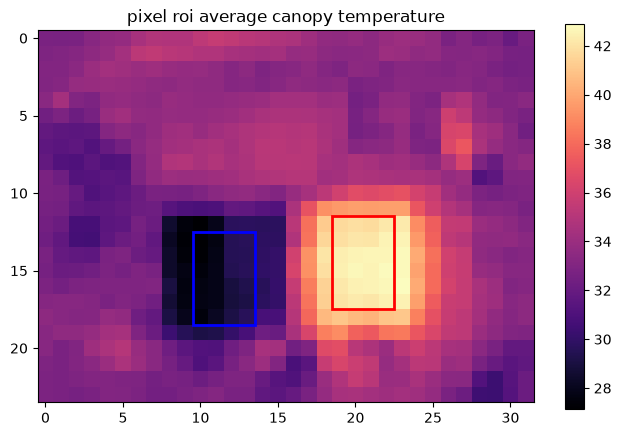

2026-09-01 10:38:44.552
2026-09-01 10:38:45.949
2026-09-01 10:38:47.064
2026-09-01 10:38:49.090
2026-09-01 10:38:51.115
2026-09-01 10:38:53.141
2026-09-01 10:38:55.167
2026-09-01 10:38:57.193
2026-09-01 10:38:59.218
2026-09-01 10:39:01.245
2026-09-01 10:39:03.270
2026-09-01 10:39:05.297
2026-09-01 10:39:07.323
2026-09-01 10:39:09.349
2026-09-01 10:39:11.375
2026-09-01 10:39:13.405
2026-09-01 10:39:15.424
2026-09-01 10:39:17.453
2026-09-01 10:39:19.476
2026-09-01 10:39:21.505
2026-09-01 10:39:23.527
2026-09-01 10:39:25.557
2026-09-01 10:39:27.599
2026-09-01 10:39:29.610
2026-09-01 10:39:31.636
2026-09-01 10:39:33.662
2026-09-01 10:39:35.689
2026-09-01 10:39:37.715
2026-09-01 10:39:39.740
2026-09-01 10:39:41.766
2026-09-01 10:39:43.797
2026-09-01 10:39:45.818
2026-09-01 10:39:47.850
2026-09-01 10:39:49.869
2026-09-01 10:39:51.902
2026-09-01 10:39:53.922
2026-09-01 10:39:55.951
2026-09-01 10:39:57.974
2026-09-01 10:40:00.004
2026-09-01 10:40:02.026
2026-09-01 10:40:04.058
2026-09-01 10:40

In [75]:
# IRT Standard validation september 1

# Read in and clean minicam_et data


def round_to_second(dt):
    # If microseconds are 500,000 or more, round up by adding 1 second
    if dt.microsecond >= 500000:
        dt += timedelta(seconds=1)
    # Truncate the microseconds
    return dt.replace(microsecond=0)



with np.load(r"C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\IRT_standards_validation\standards.npz") as data:
    # Check available arrays
    print("Archive keys:", data.files)
    
    # Extract timestamps and frames
    timestamps = data['timestamps']
    frames = data['frames']
    
    # Create dictionary
    frames_dict = {}
    for i, ts in enumerate(timestamps):
        ts = datetime.fromtimestamp(ts/1000, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]

        #print(ts)

        key = str(ts)  # Convert to string key
        frames_dict[key] = frames[i]




starttime = "2026-09-01 10:52:00.000"
endtime = "2026-09-01 15:15:00.000"



# Region 1
x1, y1 = 11, 14
# Region 2
x2, y2 = 20, 13


arr = frames_dict['2026-09-01 10:45:24.098']  # pick one array from your dict

fig, ax = plt.subplots(figsize = (8,5))
im = ax.imshow(arr, cmap='magma')
plt.colorbar(im, ax=ax)

# Rectangle takes (lower-left corner), width, height
# lower-left of the 3x3 box centered at (x,y) is (x-1.5, y-1.5)
rect = Rectangle((x1 - 1.5, y1 - 1.5), 4, 6, linewidth=2, edgecolor='blue', facecolor='none')
ax.add_patch(rect)

#add second rectangle
rect = Rectangle((x2 - 1.5, y2 - 1.5), 4, 6, linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)

ax.set_title(f'pixel roi average canopy temperature')
#plt.savefig(r'C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\IRT_standards_validation/panel_validation_withROI.jpg')
plt.show()


#Extract data from images
results = []

for key, arr in frames_dict.items():
    patch1 = arr[y1-3:y1+3, x1-2:x1+2]  # 6×6 patch
    patch2 = arr[y2-3:y2+3, x2-2:x2+2]  # 6×6 patch
    results.append({
        'TIMESTAMP': key,
        'avg_region1': patch1.mean(),
        'avg_region2': patch2.mean(),
    })
    print(key)

df = pd.DataFrame(results)

df = df.rename({'avg_region2':'black_panel', 'avg_region1':'white_panel'}, axis = 1)
df = df.melt(id_vars='TIMESTAMP', var_name='location', value_name='temperature_camera')

df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
#adjust time to match IRT
df['TIMESTAMP'] = df['TIMESTAMP'] + pd.Timedelta(seconds=3)
#round to nearest second
df['TIMESTAMP'] = df['TIMESTAMP'].dt.floor('s')


temperatures = df[(df['TIMESTAMP'] > starttime) & (df['TIMESTAMP'] < endtime)]

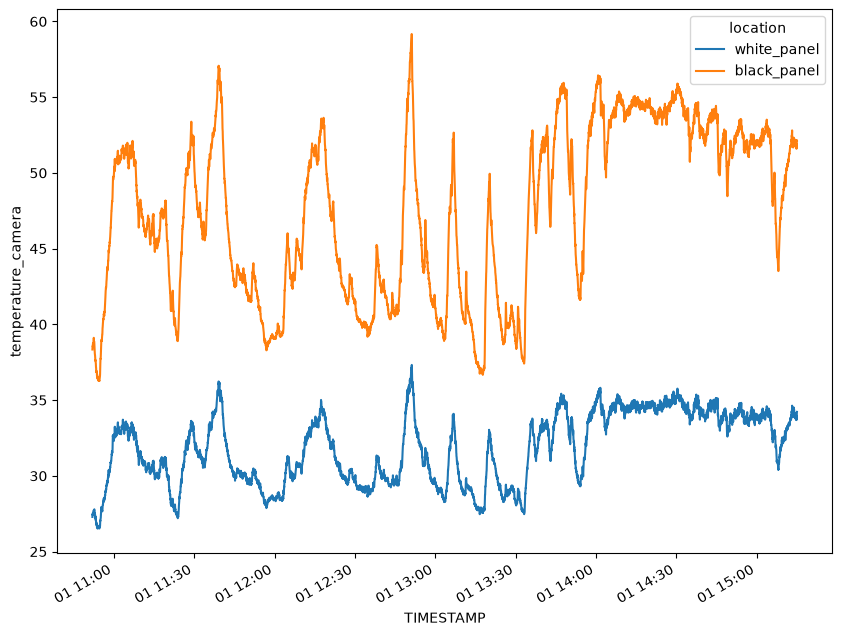

In [83]:


fig, ax = plt.subplots(figsize=(10, 8))

# Plot both series on the same 'ax'
sns.lineplot(data=temperatures, x="TIMESTAMP", y="temperature_camera", ax=ax, hue = 'location')


# Format date tick labels nicely
fig.autofmt_xdate()

#plt.savefig(r'C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\IRT_standards_validation/lineplot.jpg')

## White panel

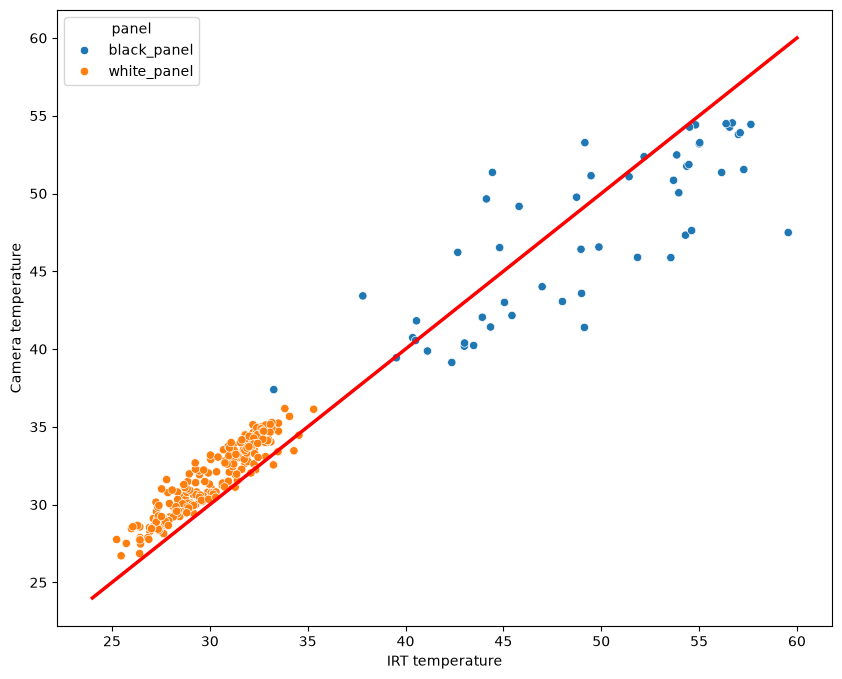

In [84]:
"""Params"""
whitepanel_subsample = '10'




"""Process white panel"""
#############################################################################################################
camera_subset = temperatures[temperatures['location'] == 'white_panel']

camera_subset['TIMESTAMP'] = pd.to_datetime(camera_subset['TIMESTAMP'])
camera_subset = camera_subset.set_index('TIMESTAMP')

camera_subset = (camera_subset
    .resample('10s')['temperature_camera']
    .last()
    .resample('1min')
    .mean()
    .reset_index()
)

#read IRT data from white panel and merge
irt_white = pd.read_csv(r"C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\IRT_standards_validation\white sept 1.csv")
irt_white['TIMESTAMP'] = pd.to_datetime(irt_white['TIMESTAMP'])
irt_white = irt_white.drop(['SensorTC', 'note'], axis = 1)
whitepanel = pd.merge(camera_subset, irt_white, on="TIMESTAMP", how="inner")
whitepanel['panel'] = 'white_panel'
###########################################################################################################




"""Process black panel"""
###########################################################################################################
# subset and average dataframe so that it will match up with the white panel
camera_subset = temperatures[temperatures['location'] == 'black_panel']

camera_subset['TIMESTAMP'] = pd.to_datetime(camera_subset['TIMESTAMP'])
camera_subset = camera_subset.set_index('TIMESTAMP')

camera_subset = (camera_subset
    .resample('1min')['temperature_camera']
    .mean()
    .resample('5min')
    .mean()
    .reset_index()
)

#read IRT data from black panel and merge
irt_black = pd.read_csv(r"C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\IRT_standards_validation\black sept 1.csv")
irt_black['TIMESTAMP'] = pd.to_datetime(irt_black['TIMESTAMP'])
irt_black = irt_black.drop(['SensorTC', 'note'], axis = 1)
blackpanel = pd.merge(camera_subset, irt_black, on="TIMESTAMP", how="inner")
blackpanel['panel'] = 'black_panel'
###########################################################################################################################




"""Concatenate both together and plot"""
both_panels = pd.concat([blackpanel, whitepanel], axis=0)






"""Plot scatterplot"""
#plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot both series on the same 'ax'
sns.scatterplot(data=both_panels, x="TargetTC", y="temperature_camera", ax=ax, hue = 'panel')

# Reference line (1:1 line)
ref_x = [24, 60]
ref_y = [24, 60]
ax.plot(ref_x, ref_y, color="red", linestyle="-", linewidth=2.5)

ax.set_xlabel('IRT temperature')
ax.set_ylabel('Camera temperature')

#plt.savefig(r'C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\IRT_standards_validation/scatterplot.jpg')

## Black panel

## Both panels

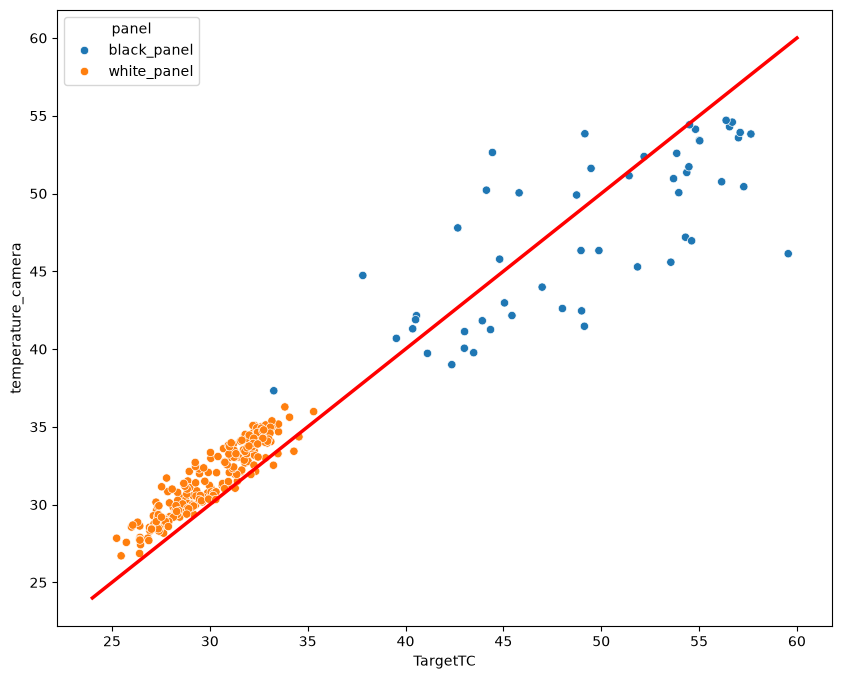

In [67]:
both_panels = pd.concat([blackpanel, whitepanel], axis=0)

#plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot both series on the same 'ax'
sns.scatterplot(data=both_panels, x="TargetTC", y="temperature_camera", ax=ax, hue = 'panel')

# Reference line (1:1 line)
ref_x = [24, 60]
ref_y = [24, 60]
ax.plot(ref_x, ref_y, color="red", linestyle="-", linewidth=2.5)

# Comparison to loadcell IRTs

## Clean and import data

In [40]:
"""READ IRT DATA"""
def read_irt(box_dir, columns):

    #initialize lists to add dataframes to
    irt_list = []
    irt_dataframes = []


    for i in os.listdir(box_dir):

        if 'IRT' in i:
            irt_record = i.split('s')[1]
            irt_record_num = int(irt_record.split('.')[0])

            #subset records to read if too many files
            if (irt_record_num > 0 and irt_record_num < 20005):
                try:
                    df = pd.read_csv(box_dir + '/'+ i, skiprows=[0, 2, 3], usecols= columns)
                except:
                    print(i)
                    print("problem extracting data from file, skipping and moving to next one")
                    continue

                #remove duplicate measurements if sensor is digital
                if "Target" in " ".join(columns):
                    df = df[df["RECORD"] % 2 != 0]
                df = df.drop('RECORD', axis = 1)

                #convert timestamp to datetime and add dataframe to list
                df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
                irt_list.append(df)
                #print(i)

                
    #concatenate all data for current box and rename the box column to treatment
    irt = pd.concat(irt_list, ignore_index = True)

    #Replace box name with treatment name and append to dataframe list
    
    #irt_dataframes.append(irt)
    
    #concatenate all dataframes together and return final df
    #all_irt = pd.concat(irt_dataframes, ignore_index=True)
    return(irt)




In [64]:
base_dir = r"C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\2026.08.24_loadcell_e_preliminary\apogee_irt/"

canopy_irt = read_irt(base_dir, ['TIMESTAMP','TT_C', 'RECORD'])
canopy_irt['TIMESTAMP'] = pd.to_datetime(canopy_irt["TIMESTAMP"])

Archive keys: ['timestamps', 'frames']
2026-08-24 09:09:42.011
2026-08-24 09:09:43.061
2026-08-24 09:09:45.116
2026-08-24 09:09:47.141
2026-08-24 09:09:49.160
2026-08-24 09:09:51.187
2026-08-24 09:09:53.204
2026-08-24 09:21:53.011
2026-08-24 09:21:54.171
2026-08-24 09:21:56.235
2026-08-24 09:21:58.262
2026-08-24 09:22:00.290
2026-08-24 09:22:02.318
2026-08-24 09:22:04.346
2026-08-24 09:22:06.374
2026-08-24 09:22:08.402
2026-08-24 09:22:10.436
2026-08-24 09:22:12.456
2026-08-24 09:22:14.488
2026-08-24 09:22:16.514
2026-08-24 09:22:18.546
2026-08-24 09:22:20.574
2026-08-24 09:22:22.621
2026-08-24 09:22:24.634
2026-08-24 09:22:26.664
2026-08-24 09:22:28.693
2026-08-24 09:22:30.722
2026-08-24 09:22:32.752
2026-08-24 09:22:34.781
2026-08-24 09:22:36.811
2026-08-24 09:22:38.840
2026-08-24 09:22:40.874
2026-08-24 09:22:42.898
2026-08-24 09:22:44.931
2026-08-24 09:22:46.958
2026-08-24 09:22:48.991
2026-08-24 09:22:51.018
2026-08-24 09:22:53.051
2026-08-24 09:22:55.078
2026-08-24 09:22:57.111
2

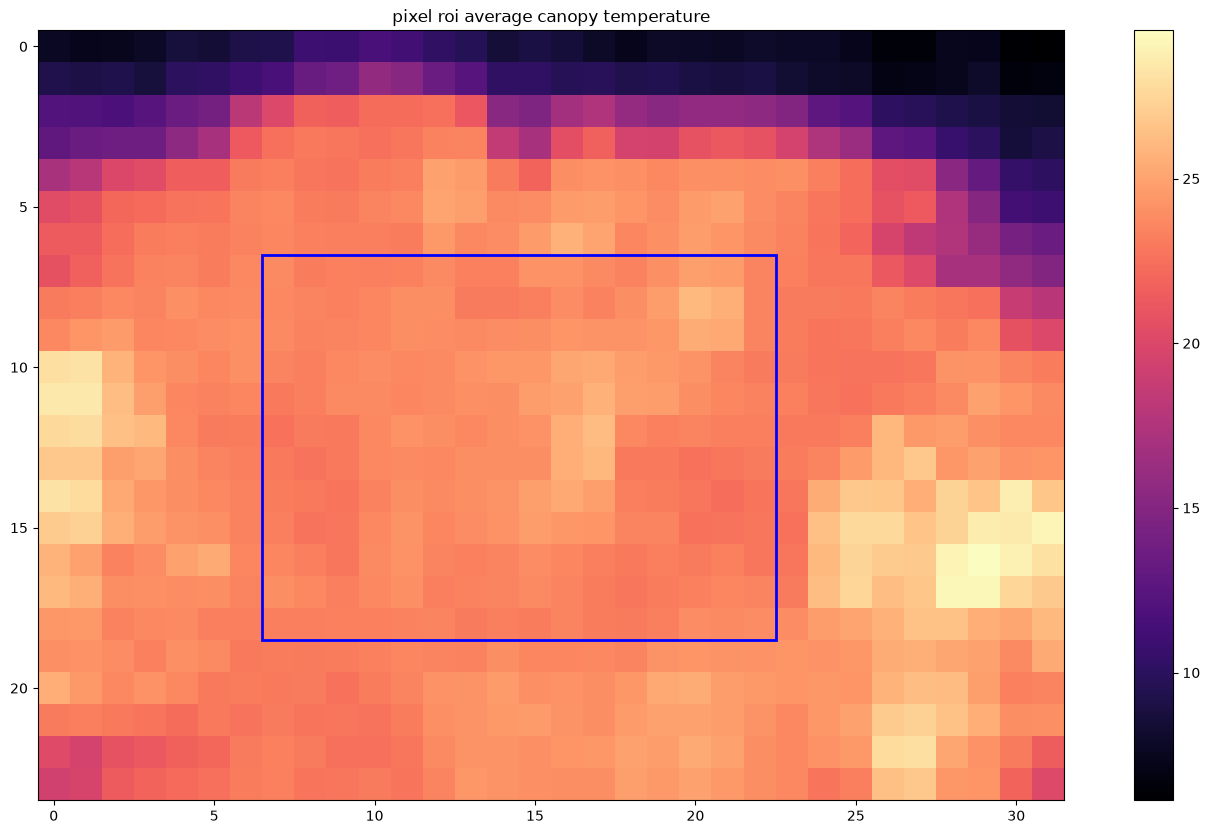

In [158]:
def round_to_second(dt):
    # If microseconds are 500,000 or more, round up by adding 1 second
    if dt.microsecond >= 500000:
        dt += timedelta(seconds=1)
    # Truncate the microseconds
    return dt.replace(microsecond=0)



with np.load(r"C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\2026.08.24_loadcell_e_preliminary\minicam\loadcell_e.npz") as data:
    # Check available arrays
    print("Archive keys:", data.files)
    
    # Extract timestamps and frames
    timestamps = data['timestamps']
    frames = data['frames']
    
    # Create dictionary
    frames_dict = {}
    for i, ts in enumerate(timestamps):
        ts = datetime.fromtimestamp(ts/1000, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]

        print(ts)

        key = str(ts)  # Convert to string key
        frames_dict[key] = frames[i]




starttime = "2026-08-24 09:27:00.000"
endtime = "2026-08-24 14:30:00.000"



x, y = 8, 8
arr = frames_dict['2026-08-24 09:55:36.036']  # pick one array from your dict

fig, ax = plt.subplots(figsize = (18,10))
im = ax.imshow(arr, cmap='magma')
plt.colorbar(im, ax=ax)

# Rectangle takes (lower-left corner), width, height
# lower-left of the 3x3 box centered at (x,y) is (x-1.5, y-1.5)
rect = Rectangle((x - 1.5, y - 1.5), 16, 12, linewidth=2, edgecolor='blue', facecolor='none')
ax.add_patch(rect)

ax.set_title(f'pixel roi average canopy temperature')
plt.savefig(r'C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints\microcontroller_imaging\validation_loadcells/side_canopy_wavelet_withROI.jpg')
plt.show()




results = {}

for key, arr in frames_dict.items():
    #print(key)
    # slice is [row_start:row_end, col_start:col_end]
    # rows correspond to y, columns correspond to x
    patch = arr[y-1:y+2, x-1:x+2]
    results[key] = patch.mean()

    #print(key)


df = pd.DataFrame(list(results.items()), columns=['TIMESTAMP', 'minicam_temp'])
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

df = df[(df["TIMESTAMP"] > starttime) & (df["TIMESTAMP"] < endtime)]
df['TIMESTAMP'] = df['TIMESTAMP'].dt.floor('s')


Text(0.5, 0, 'Timestamp')

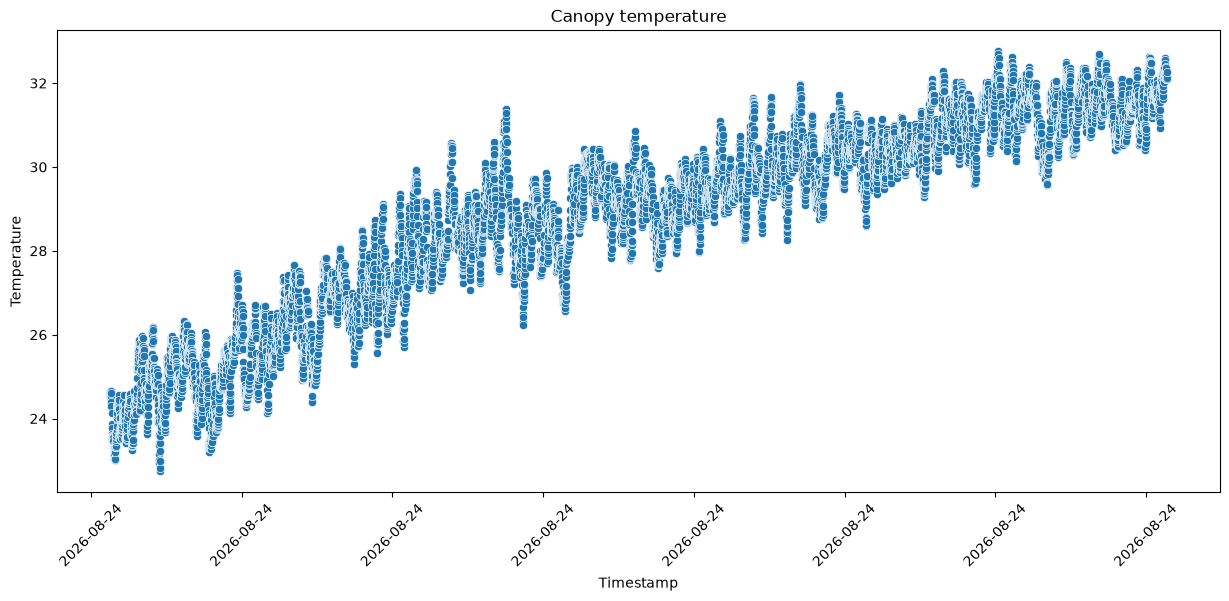

In [45]:


fig, ax = plt.subplots(figsize = (15,6))
sns.scatterplot(data = df, x = 'timestamp', y = 'canopy_temp', ax = ax)
ax.set_title('Canopy temperature')

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))

# Rotate X-tick labels
ax.tick_params(axis="x", rotation=45)
#plt.setp(bax.axs[-1].get_xticklabels(), ha="right", rotation_mode="anchor")

ax.set_ylabel("Temperature")
ax.set_xlabel("Timestamp", labelpad = 5)
    
#plt.savefig(r'')

Text(0.5, 0, 'Timestamp')

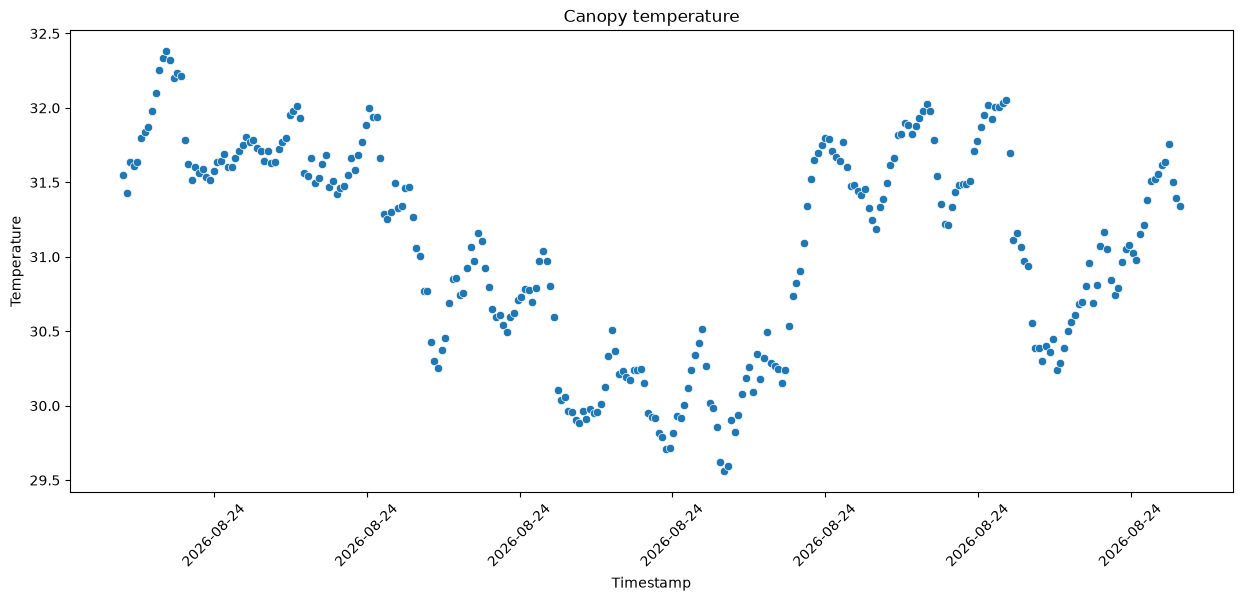

In [47]:
starttime_plot = "2026-08-24 13:50:00.000"
endtime_plot = "2026-08-24 14:00:00.000"
plot_df = df[(df["timestamp"] >= starttime_plot) & (df["timestamp"] <= endtime_plot)]



fig, ax = plt.subplots(figsize = (15,6))
sns.scatterplot(data = plot_df, x = 'timestamp', y = 'canopy_temp', ax = ax)
ax.set_title('Canopy temperature')

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))

# Rotate X-tick labels
ax.tick_params(axis="x", rotation=45)
#plt.setp(bax.axs[-1].get_xticklabels(), ha="right", rotation_mode="anchor")

ax.set_ylabel("Temperature")
ax.set_xlabel("Timestamp", labelpad = 5)
    
#plt.savefig(r'')

In [149]:
temp = pd.read_csv(r"C:\Users\samed\OneDrive\Documents\postdoc\minicam_et_data\2026.08.24_loadcell_e_preliminary\minicam\dht_log.csv")

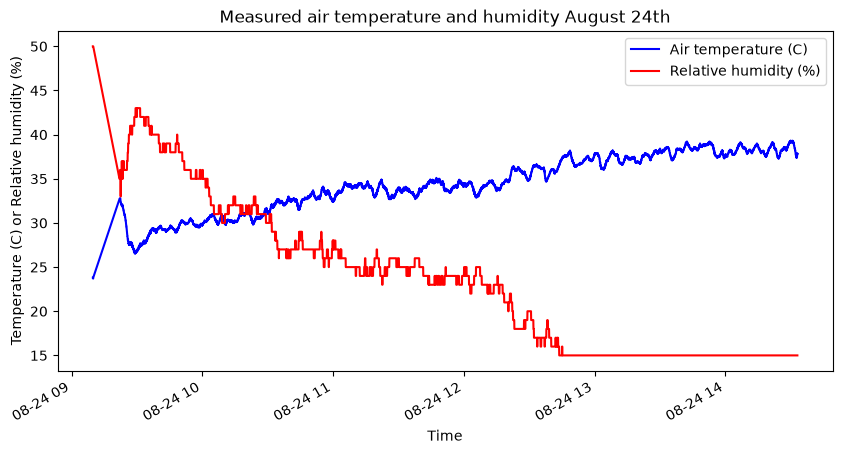

In [154]:
temp['datetime'] = pd.to_datetime(temp['datetime'])

fig, ax = plt.subplots(figsize=(10, 5))

# Plot both series on the same 'ax'
sns.lineplot(data=temp, x="datetime", y="temperature_C", ax=ax, label="Air temperature (C)", color="b")
sns.lineplot(data=temp, x="datetime", y="humidity_pct", ax=ax, label="Relative humidity (%)", color="r")

# Customize titles and labels
ax.set_title("Measured air temperature and humidity August 24th")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (C) or Relative humidity (%)")

# Format date tick labels nicely
fig.autofmt_xdate()

plt.savefig(r"C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints\microcontroller_imaging\validation_loadcells/t_rh.jpg")

#plt.show()

In [ ]:
temp

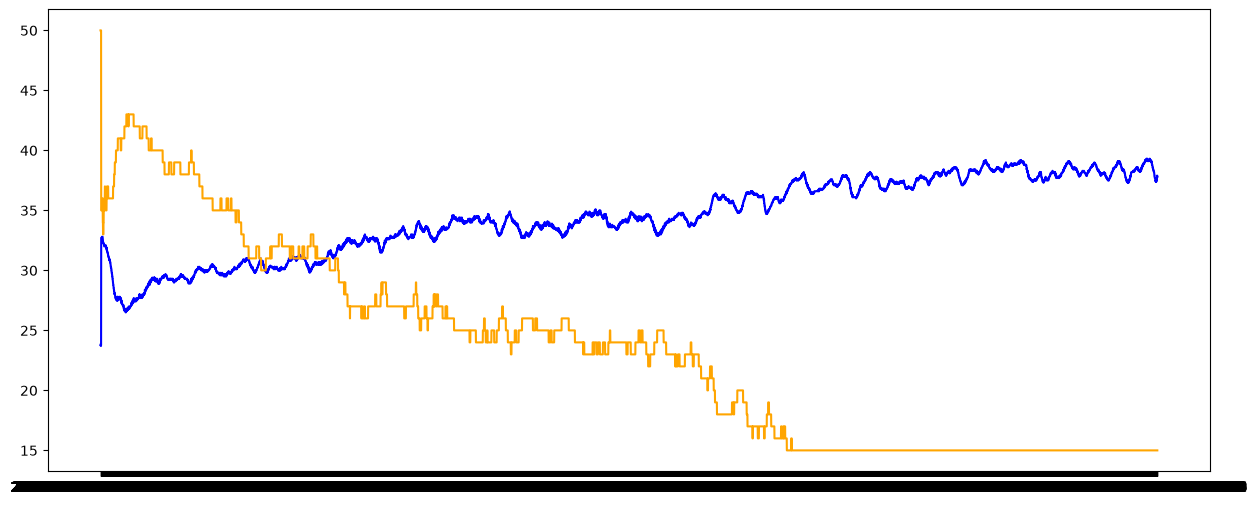

In [53]:

fig, ax = plt.subplots(figsize = (15,6))

plt.plot(temp["datetime"], temp["temperature_C"], color="blue")
plt.plot(temp["datetime"], temp["humidity_pct"], color="orange")

In [ ]:
starttime_plot = "2026-08-24 09:30:00.000"
endtime_plot = "2026-08-24 14:30:00.000"
plot_df = df[(df["timestamp"] >= starttime_plot) & (df["timestamp"] <= endtime_plot)]



fig, ax = plt.subplots(figsize = (15,6))
sns.scatterplot(data = temp, x = 'timestamp', y = 'temperature_C', ax = ax)
ax.set_title('Canopy temperature')

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))

# Rotate X-tick labels
ax.tick_params(axis="x", rotation=45)
#plt.setp(bax.axs[-1].get_xticklabels(), ha="right", rotation_mode="anchor")

ax.set_ylabel("Temperature")
ax.set_xlabel("Timestamp", labelpad = 5)
    
#plt.savefig(r'')

## Validation against IRT

In [69]:
both = pd.merge(df, canopy_irt, on="TIMESTAMP", how="inner")

In [117]:
xy = np.vstack([both['TT_C'].values, both['minicam_temp'].values])
density = gaussian_kde(xy)(xy)

# 3. Sort points so high-density points are plotted on top
idx = density.argsort()
x, y, density = x[idx], y[idx], density[idx]




starttime_plot = "2026-08-24 09:30:00.000"
endtime_plot = "2026-08-24 14:30:00.000"
plot_df = both[(both["TIMESTAMP"] >= starttime_plot) & (both["TIMESTAMP"] <= endtime_plot)]



fig, ax = plt.subplots(figsize=(10, 8))

# Plot both series on the same 'ax'
sns.scatterplot(data=plot_df, 
                x="TT_C", 
                y="minicam_temp", 
                hue=density,
                palette="viridis",  # Colormap choice (e.g., 'magma', 'plasma', 'rocket')
                edgecolor=None,
                s=25,
                ax = ax)

norm = plt.Normalize(density.min(), density.max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
ax.get_legend().remove()  # Remove standard discrete legend
fig.colorbar(sm, ax=ax, label="Density")



x = [24, 34]
y = [24, 34]
ax.plot(x, y)


# Customize titles and labels
ax.set_xlabel("IRT")
ax.set_ylabel("MLX90640")

plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

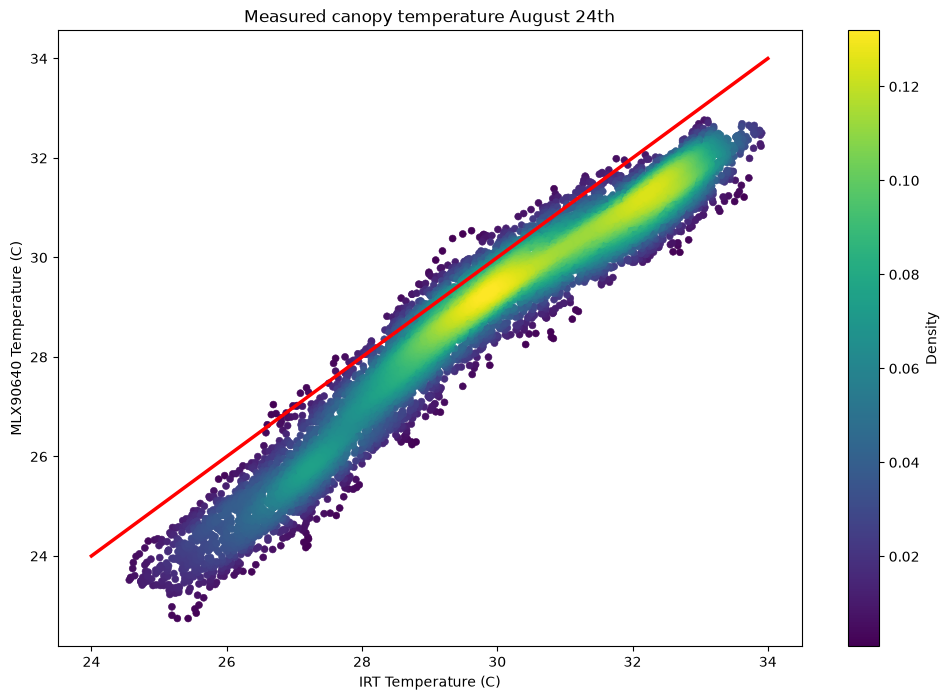

In [131]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde

# 1. Filter plot_df first
starttime_plot = "2026-08-24 09:30:00.000"
endtime_plot = "2026-08-24 14:30:00.000"
plot_df = both[
    (both["TIMESTAMP"] >= starttime_plot) & (both["TIMESTAMP"] <= endtime_plot)
].copy()

# Drop NaNs in target columns to prevent KDE calculation failure
plot_df = plot_df.dropna(subset=["TT_C", "minicam_temp"])

# 2. Calculate density on plot_df
xy = np.vstack([plot_df["TT_C"].values, plot_df["minicam_temp"].values])
plot_df["density"] = gaussian_kde(xy)(xy)

# 3. Sort plot_df by density so high-density points plot on top
plot_df = plot_df.sort_values(by="density")

# 4. Plot
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x="TT_C",
    y="minicam_temp",
    hue="density",
    palette="viridis",
    edgecolor=None,
    s=25,
    ax=ax,
)

# 5. Colorbar setup
norm = plt.Normalize(plot_df["density"].min(), plot_df["density"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
ax.get_legend().remove()
fig.colorbar(sm, ax=ax, label="Density")

# Reference line (1:1 line)
ref_x = [24, 34]
ref_y = [24, 34]
ax.plot(ref_x, ref_y, color="red", linestyle="-", linewidth=2.5)

# Customize titles and labels
ax.set_title("Measured canopy temperature August 24th")
ax.set_xlabel("IRT Temperature (C)")
ax.set_ylabel("MLX90640 Temperature (C)")

plt.savefig(r"C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints\microcontroller_imaging\validation_loadcells/scatterplot.jpg")

plt.show()

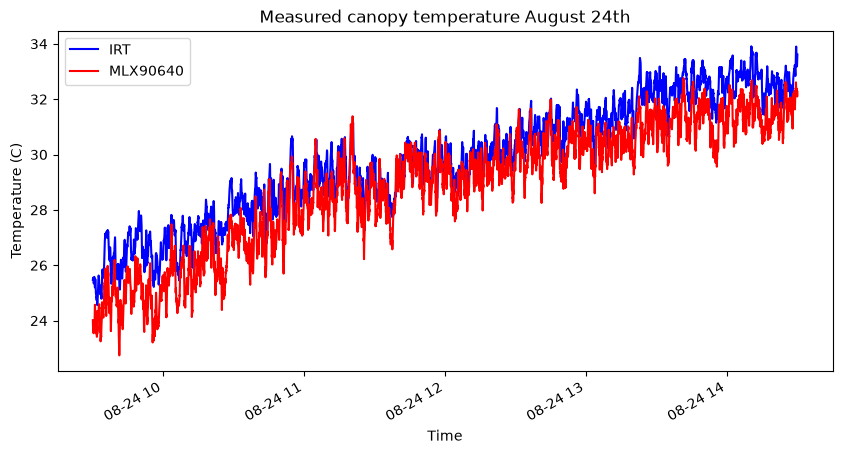

In [135]:
starttime_plot = "2026-08-24 09:30:00.000"
endtime_plot = "2026-08-24 14:30:00.000"
plot_df = both[(both["TIMESTAMP"] >= starttime_plot) & (both["TIMESTAMP"] <= endtime_plot)]



fig, ax = plt.subplots(figsize=(10, 5))

# Plot both series on the same 'ax'
sns.lineplot(data=plot_df, x="TIMESTAMP", y="TT_C", ax=ax, label="IRT", color="b")
sns.lineplot(data=plot_df, x="TIMESTAMP", y="minicam_temp", ax=ax, label="MLX90640", color="r")

# Customize titles and labels
ax.set_title("Measured canopy temperature August 24th")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (C)")

# Format date tick labels nicely
fig.autofmt_xdate()

plt.savefig(r"C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints\microcontroller_imaging\validation_loadcells/alltime.jpg")

plt.show()

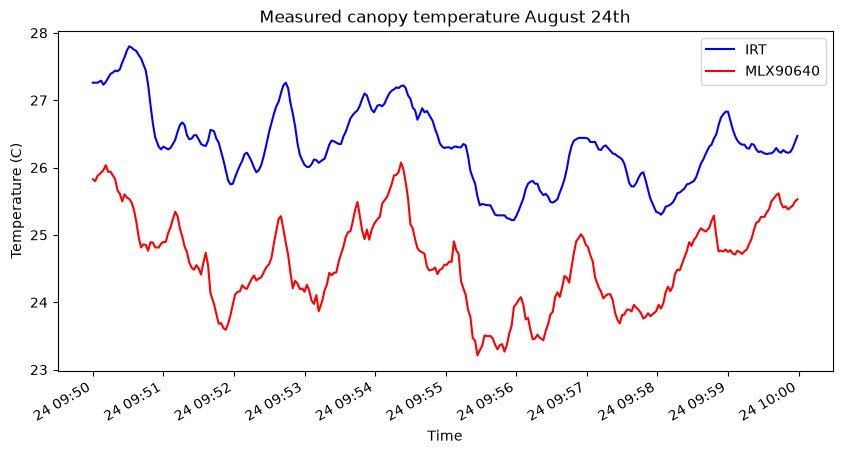

In [141]:
starttime_plot = "2026-08-24 09:50:00.000"
endtime_plot = "2026-08-24 10:00:00.000"
plot_df = both[(both["TIMESTAMP"] >= starttime_plot) & (both["TIMESTAMP"] <= endtime_plot)]



fig, ax = plt.subplots(figsize=(10, 5))

# Plot both series on the same 'ax'
sns.lineplot(data=plot_df, x="TIMESTAMP", y="TT_C", ax=ax, label="IRT", color="b")
sns.lineplot(data=plot_df, x="TIMESTAMP", y="minicam_temp", ax=ax, label="MLX90640", color="r")

# Customize titles and labels
ax.set_title("Measured canopy temperature August 24th")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (C)")

# Format date tick labels nicely

fig.autofmt_xdate()
plt.savefig(r"C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints\microcontroller_imaging\validation_loadcells/early.jpg")

plt.show()

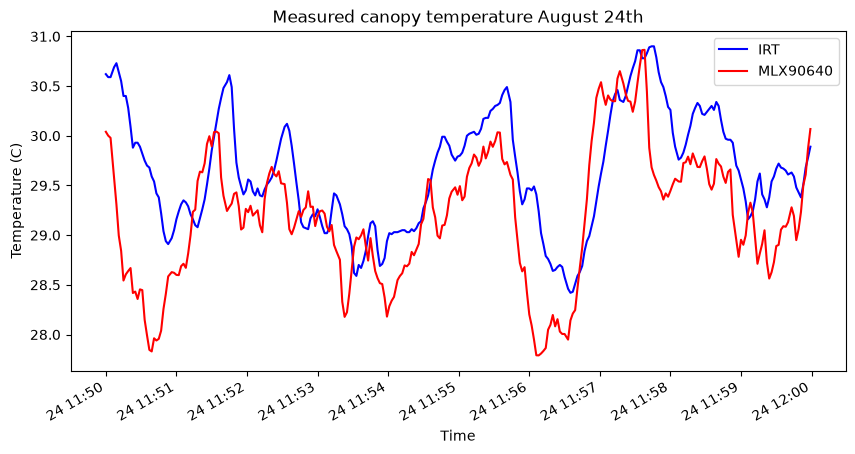

In [143]:
starttime_plot = "2026-08-24 11:50:00.000"
endtime_plot = "2026-08-24 12:00:00.000"
plot_df = both[(both["TIMESTAMP"] >= starttime_plot) & (both["TIMESTAMP"] <= endtime_plot)]



fig, ax = plt.subplots(figsize=(10, 5))

# Plot both series on the same 'ax'
sns.lineplot(data=plot_df, x="TIMESTAMP", y="TT_C", ax=ax, label="IRT", color="b")
sns.lineplot(data=plot_df, x="TIMESTAMP", y="minicam_temp", ax=ax, label="MLX90640", color="r")

# Customize titles and labels
ax.set_title("Measured canopy temperature August 24th")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (C)")

# Format date tick labels nicely
fig.autofmt_xdate()

plt.savefig(r"C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints\microcontroller_imaging\validation_loadcells/middle.jpg")

plt.show()

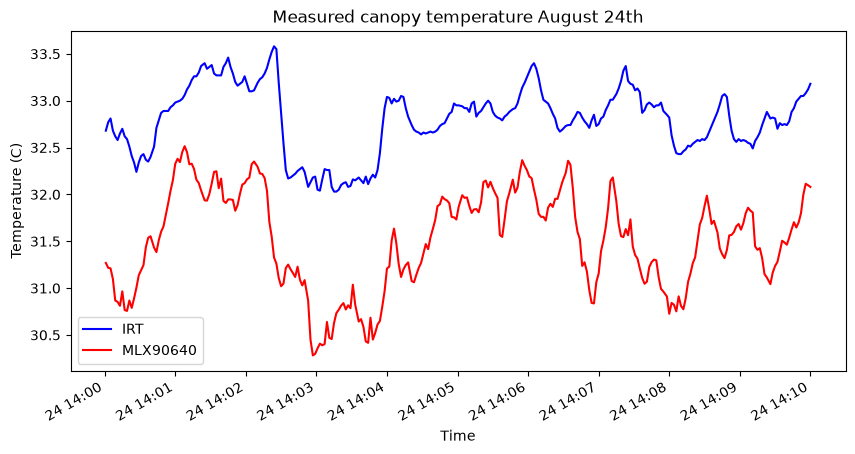

In [145]:
starttime_plot = "2026-08-24 14:00:00.000"
endtime_plot = "2026-08-24 14:10:00.000"
plot_df = both[(both["TIMESTAMP"] >= starttime_plot) & (both["TIMESTAMP"] <= endtime_plot)]



fig, ax = plt.subplots(figsize=(10, 5))

# Plot both series on the same 'ax'
sns.lineplot(data=plot_df, x="TIMESTAMP", y="TT_C", ax=ax, label="IRT", color="b")
sns.lineplot(data=plot_df, x="TIMESTAMP", y="minicam_temp", ax=ax, label="MLX90640", color="r")

# Customize titles and labels
ax.set_title("Measured canopy temperature August 24th")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (C)")

# Format date tick labels nicely
fig.autofmt_xdate()

plt.savefig(r"C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints\microcontroller_imaging\validation_loadcells/late.jpg")

plt.show()

# Preliminary test: rootstock block

Loaded 603 frames from C:\Users\samed\OneDrive\Documents\Arduino\overhead_rootstock_block.pkl


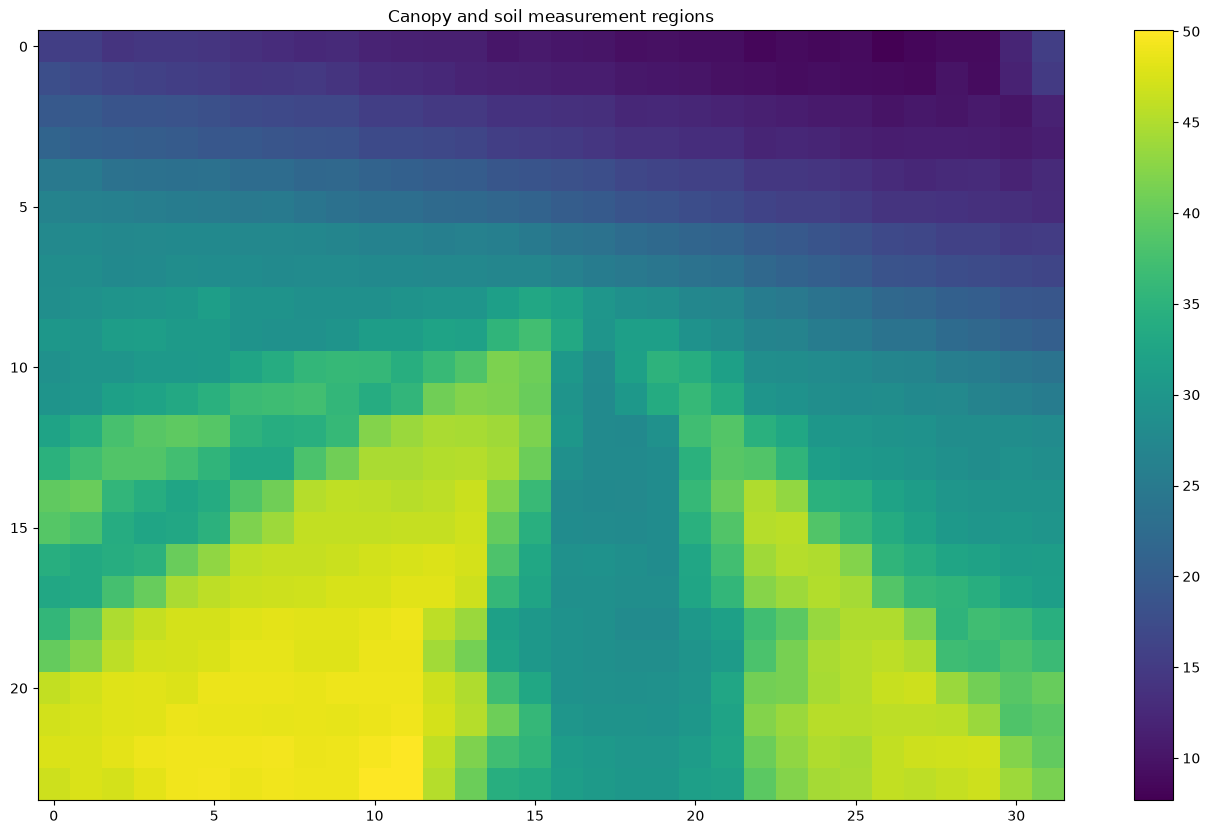

2026-08-14 13:58:11.516
2026-08-14 13:58:12.038
2026-08-14 13:58:12.783
2026-08-14 13:58:13.305
2026-08-14 13:58:14.050
2026-08-14 13:58:14.572
2026-08-14 13:58:15.317
2026-08-14 13:58:15.839
2026-08-14 13:58:16.584
2026-08-14 13:58:17.106
2026-08-14 13:58:17.851
2026-08-14 13:58:18.374
2026-08-14 13:58:19.118
2026-08-14 13:58:19.640
2026-08-14 13:58:20.385
2026-08-14 13:58:20.907
2026-08-14 13:58:21.652
2026-08-14 13:58:22.174
2026-08-14 13:58:22.920
2026-08-14 13:58:23.594
2026-08-14 13:58:24.246
2026-08-14 13:58:24.905
2026-08-14 13:58:25.561
2026-08-14 13:58:26.252
2026-08-14 13:58:26.921
2026-08-14 13:58:27.583
2026-08-14 13:58:28.250
2026-08-14 13:58:28.970
2026-08-14 13:58:29.571
2026-08-14 13:58:29.899
2026-08-14 13:58:30.521
2026-08-14 13:58:31.043
2026-08-14 13:58:31.788
2026-08-14 13:58:32.311
2026-08-14 13:58:33.056
2026-08-14 13:58:33.578
2026-08-14 13:58:34.322
2026-08-14 13:58:34.845
2026-08-14 13:58:35.590
2026-08-14 13:58:36.112
2026-08-14 13:58:36.856
2026-08-14 13:58

In [66]:



# ----- Settings you may need to change -----
PICKLE_PATH = r"C:\Users\samed\OneDrive\Documents\Arduino\overhead_rootstock_block.pkl"   # Path to the pickled frames dictionary
SAVE_PATH = r'C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints/side_canopy_data.jpg'  # Use .mp4 (needs ffmpeg) or .gif (no extra install)
# ---------------------------------------------

with open(PICKLE_PATH, "rb") as f:
    frames_dict = pickle.load(f)

if not frames_dict:
    print("No frames found in pickle file.")
    

# Sort by timestamp so playback is in chronological order
timestamps = sorted(frames_dict.keys())
frames = [frames_dict[t] for t in timestamps]
print(f"Loaded {len(frames)} frames from {PICKLE_PATH}")




x, y = 8, 18
arr = frames_dict['2026-08-14 14:01:16.139']  # pick one array from your dict

fig, ax = plt.subplots(figsize = (18,10))
im = ax.imshow(arr, cmap='viridis')
plt.colorbar(im, ax=ax)

# Rectangle takes (lower-left corner), width, height
# lower-left of the 3x3 box centered at (x,y) is (x-1.5, y-1.5)
rect = Rectangle((x - 1.5, y - 1.5), 3, 3, linewidth=2, edgecolor='red', facecolor='none')
#ax.add_patch(rect)

x, y = 18, 18

rect = Rectangle((x - 1.5, y - 1.5), 3, 3, linewidth=2, edgecolor='yellow', facecolor='none')
#ax.add_patch(rect)

ax.set_title(f'Canopy and soil measurement regions')
#plt.savefig(r'C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints/overhead_vineyard_norectangle.jpg')
plt.show()



# Region 1
x1, y1 = 8, 18
# Region 2
x2, y2 = 18, 18

results = []

for key, arr in frames_dict.items():
    patch1 = arr[y1-1:y1+2, x1-1:x1+2]
    patch2 = arr[y2-1:y2+2, x2-1:x2+2]
    results.append({
        'key': key,
        'avg_region1': patch1.mean(),
        'avg_region2': patch2.mean(),
    })
    print(key)

df = pd.DataFrame(results)

df = df.rename({'avg_region2':'canopy_temperature', 'avg_region1':'ground_temperature'}, axis = 1)
df = df.melt(id_vars='key', var_name='location', value_name='temperature')




df["key"] = pd.to_datetime(df["key"])

# 2. Subtract the start time and convert elapsed duration to seconds
df["elapsed_seconds"] = (df["key"] - df["key"].min()).dt.total_seconds()

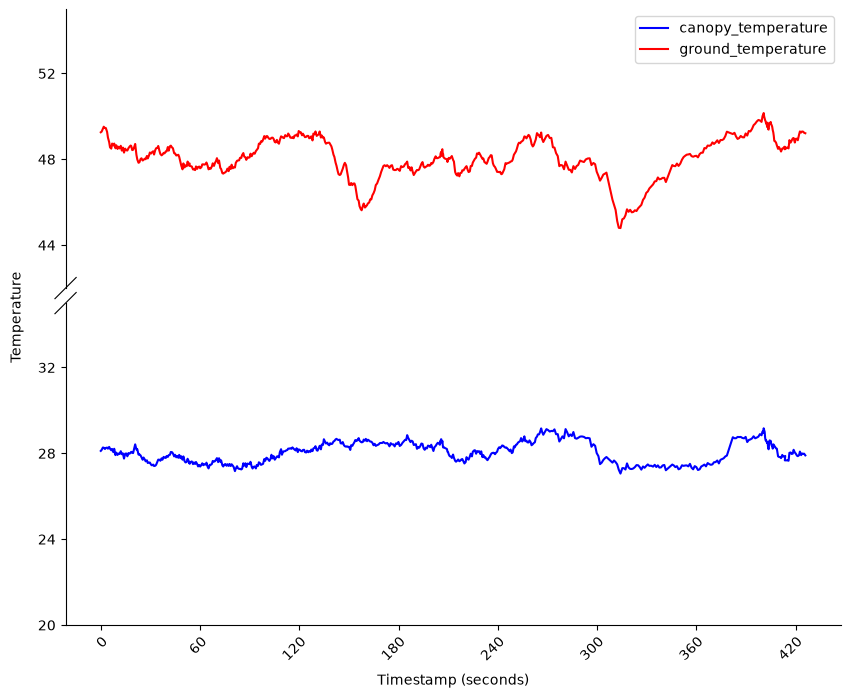

In [75]:


# 1. Initialize brokenaxes
bax = brokenaxes(ylims=((20, 35), (42, 55)), hspace=0.05, fig=plt.figure(figsize=(10, 8)))

# 2. Plot data
bax.plot(
    df[df["location"] == "canopy_temperature"]["elapsed_seconds"],
    df[df["location"] == "canopy_temperature"]["temperature"],
    label="canopy_temperature",
    color="blue",
)
bax.plot(
    df[df["location"] == "canopy_temperature"]["elapsed_seconds"],
    df[df["location"] == "ground_temperature"]["temperature"],
    label="ground_temperature",
    color="red",
)

# 3. Customize X-ticks (applied to the bottom subplot in bax.axs)
# Reduce the number of X ticks (e.g., maximum 8 ticks)
bax.axs[-1].xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))

# Rotate X-tick labels
bax.axs[-1].tick_params(axis="x", rotation=45)
plt.setp(bax.axs[-1].get_xticklabels(), ha="right", rotation_mode="anchor")

# 4. Customize Y-ticks (applied across all subplots in bax.axs)
for ax in bax.axs:
    # Limit number of Y ticks per split section (e.g., max 4 ticks per section)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

# 5. Add labels and legend
bax.set_ylabel("Temperature")
bax.set_xlabel("Timestamp (seconds)", labelpad = 35)
bax.legend()

plt.savefig(r'C:\Users\samed\OneDrive\Documents\postdoc\figures_powerpoints/overhead_canopy_data.jpg')
plt.show()